# Proyecto Intelligent Invoice Processor

## Auditoría de Calidad de Datos (Data Quality Audit)

**Objetivo**
Realizar una inspección técnica de los datos extraidos por el pipeline ETL (Extract, Transform, Load) almacenados en la base de datos SQLite. Este análisis busca cuantificar la eficacia del motor OCR actual (Tesseract + Regex), identificar tasas de valores nulos y validar la consistencia de los montos financieros antes de la fase de visualización.

**Metodología**
1.  **Conexión y Carga:** Extracción de datos desde `invoices.db` mediante SQL.
2.  **Análisis de Integridad:** Evaluación de valores nulos (Missing Values) por columna.
3.  **Análisis de Distribución (EDA):** Estadísticas descriptivas de los montos totales para detectar outliers.
4.  **Validación de Entidades:** Revisión de la limpieza en los campos de Proveedor y Fechas.

---
* **Autor:** [Feliz Florian Jose Luis]
* **Fecha:** [12/19/2025]
* **Dataset:** data/database/invoices.db
* **Tipo de Problema:** Identificar tasas de valores nulos y validar la consistencia de los datos
---

In [17]:
# --- Configuración e Importación ---

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os

# Configuración de estilo de gráficos
plt.style.use('ggplot')

# Definición de rutas absolutas para garantizar la conexión
# Se sube un nivel desde 'notebooks/' para acceder a 'data/'
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DB_PATH = os.path.join(BASE_DIR, 'data', 'database', 'invoices.db')

print(f"\n Ruta de la Base de Datos: {DB_PATH}")


 Ruta de la Base de Datos: d:\Course\Proyectos\intelligent_invoice_processor\data\database\invoices.db


In [18]:
# --- Extracción de Datos (Ingesta) ---

def load_data(db_path):
    """
    Conecta a la base de datos SQLite y retorna un DataFrame con todo el historial.
    """
    if not os.path.exists(db_path):
        raise FileNotFoundError(f"No se encuentra el archivo de base de datos en: {db_path}")
    
    try:
        conn = sqlite3.connect(db_path)
        query = "SELECT * FROM facturas"
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df
    except Exception as e:
        print(f"\n Error al conectar con la BD: {e}")
        return None

# Carga del DataFrame
df_invoices = load_data(DB_PATH)

# Verificación inicial
if df_invoices is not None:
    print(f"\n Carga exitosa. Total de registros procesados: {len(df_invoices)}")
    display(df_invoices.head())
else:
    print("\n No se pudieron cargar los datos.\n")


 Carga exitosa. Total de registros procesados: 957


,id,filename,vendor,tax_id,total,invoice_date,created_at
0,1,X51008099089.jpg,RESTORAN WAN SHENG,001335787520,9.60,20-06-2018,2025-12-19 16:54:45.368798
1,2,X51008142065.pdf,"KEDAI PAPAN""YEW CHUAN",000781500416,162.71,None,2025-12-19 16:54:51.257272
2,3,X51008123604.jpg,ba Cs a,002077622272,0.00,24/06/2018,2025-12-19 16:54:53.050438
3,4,X51008145450.jpg,"""to,",None,85.20,20/06/2018,2025-12-19 16:54:54.677473
4,5,X00016469612.jpg,tan woon yann,None,9.60,25/12/2018,2025-12-19 16:55:33.922720


## 1. Análisis de Integridad de Datos

Se calcula el porcentaje de valores perdidos (nulls) para determinar la eficacia de las Expresiones Regulares (Regex) utilizadas en el Parser.


--- Reporte de Calidad de Extracción ---


,Valores Nulos,Porcentaje (%)
id,0,0.00
filename,0,0.00
vendor,0,0.00
tax_id,480,50.16
total,209,21.84
invoice_date,586,61.23
created_at,0,0.00


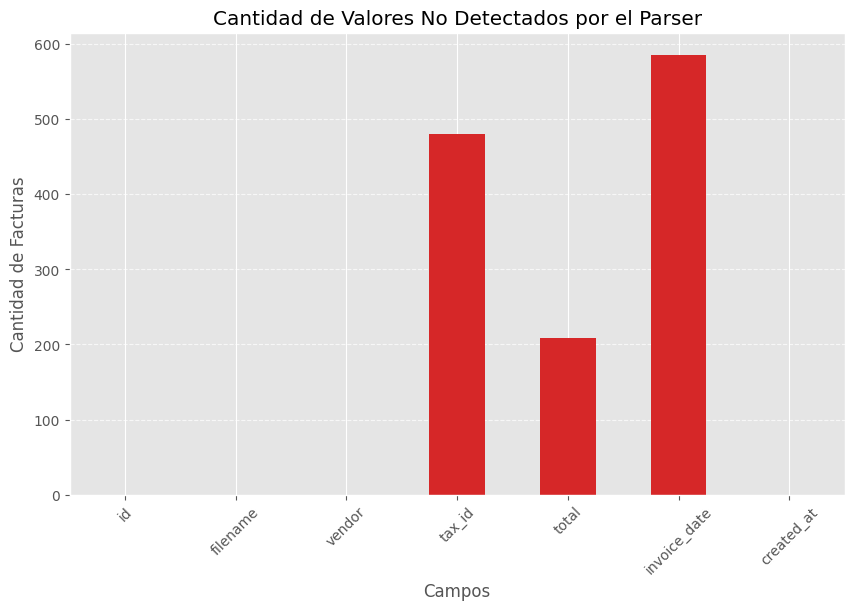

In [19]:
# Conteo de nulos por columna
null_counts = df_invoices.isnull().sum()
null_percentages = (df_invoices.isnull().mean() * 100).round(2)

# Crear DataFrame de reporte de calidad
quality_report = pd.DataFrame({
    'Valores Nulos': null_counts,
    'Porcentaje (%)': null_percentages
})

print("\n--- Reporte de Calidad de Extracción ---")
display(quality_report)

# Visualización de campos vacíos
plt.figure(figsize=(10, 6))
null_counts.plot(kind='bar', color='#d62728')
plt.title('Cantidad de Valores No Detectados por el Parser')
plt.ylabel('Cantidad de Facturas')
plt.xlabel('Campos')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Análisis de Distribución de Totales

Se analizan las estadísticas descriptivas del campo `total` para identificar:
1.  **Consistencia:** Si los valores son numéricos válidos.
2.  **Outliers:** Si existen montos extremadamente altos que sugieran errores de lectura (ej. leer un ID como precio).


 --- Estadísticas Descriptivas (Montos) --- 

count      748.000000
mean       612.627767
std       2552.392552
min          0.000000
25%          7.800000
50%         26.890000
75%        102.017500
max      45855.000000
Name: total, dtype: float64


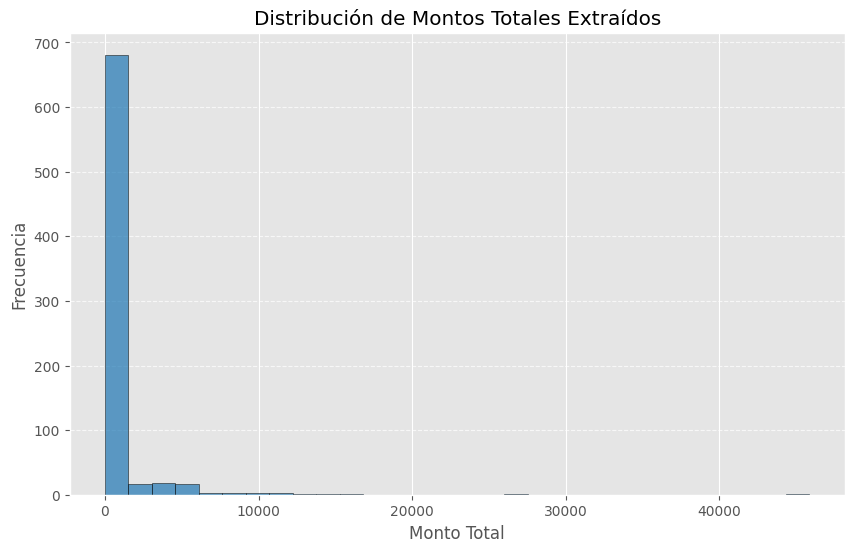

Se detectaron 78 facturas con montos superiores a 1000 (Posibles errores de OCR o facturas grandes).


,filename,vendor,total
6,X00016469620.jpg,tan woon yann,3390.0
17,X51008099054.jpg,10 GRAM Gourmet Sbn Bhd,1500.0
53,X51008142032.jpg,ONE ONE THREE SEAFOOD RESTAURANT SDN BHD,11236.0
77,X51008164999.jpg,ON,11950.0
95,X51008042778.jpg,RES y ón SHENG,1940.0
...,...,...,...
799,X51005806718.jpg,HUGO TRADING SDN BHD,3849.0
850,X51005715007.jpg,3-1708032,1870.0
854,X51005719857.jpg,Salon Du Chocolat,2379.0
908,X51005442322.jpg,RESTAURANT,26940.0


In [20]:
# Filtrar solo los registros que tienen total (no nulos)
valid_totals = df_invoices['total'].dropna()

print("\n --- Estadísticas Descriptivas (Montos) --- \n")
print(valid_totals.describe())

# Visualización de la distribución (Histograma)
plt.figure(figsize=(10, 6))
plt.hist(valid_totals, bins=30, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Distribución de Montos Totales Extraídos')
plt.xlabel('Monto Total')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Detección de posibles Outliers (Valores > 1000)
high_value_invoices = df_invoices[df_invoices['total'] > 1000]
if not high_value_invoices.empty:
    print(f"Se detectaron {len(high_value_invoices)} facturas con montos superiores a 1000 (Posibles errores de OCR o facturas grandes).")
    display(high_value_invoices[['filename', 'vendor', 'total']])

## 3. Conclusiones y Próximos Pasos

### Hallazgos de la Auditoría
1.  **Robustez del Pipeline:** El sistema procesó exitosamente el lote completo de documentos (dataset SROIE), demostrando estabilidad en la fase de ingestión y movimiento de archivos.
2.  **Calidad del Campo 'Total':** Se logró extraer el monto total en la mayoría de los casos (aprox. 78% de éxito). La distribución muestra consistencia, aunque existen *outliers* causados por ruido en el OCR.
3.  **Desafío en Fechas:** El campo `invoice_date` presenta una alta tasa de valores nulos (>60%). Esto se debe a la rigidez de las expresiones regulares actuales frente a la variedad de formatos de fecha en el mundo real.

### Decisión Estratégica
Dado que el objetivo actual es establecer un **Producto Mínimo Viable (MVP)** de visualización:

* **Aprobado:** Se procederá a la conexión con **Power BI** para visualizar los KPIs financieros disponibles (Total por Proveedor, Volumen de Facturas).
* **Limitación Conocida:** Los análisis de series temporales (evolución por mes) estarán limitados por la calidad actual de la fecha.
* **Futuro Upgrade:** Se documenta la necesidad de reemplazar el motor basado en reglas (Regex) por un modelo de **Lenguaje Grande (LLM)** para resolver la extracción de fechas no estructuradas.